In [ ]:
from pathlib import Path
import datetime as dt
import xarray as xr
import numpy as np
import pandas as pd
import dask
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib.cm import get_cmap
from matplotlib import pyplot as plt
import wrf

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
resolution = 12         # 4 or 12 km
projdir = Path().resolve().parents[0]

datadir = projdir / "evaluation/working"
staticdatadir = Path(f"/import/SNAP/cwaigl/wrf_era5")
chunking = {
    4: ['auto', 'auto'],
    12: ['auto', 'auto']
}

In [ ]:
winddatapth = datadir / f"windavg_monthly_{resolution}km.nc"

In [ ]:
windDS = xr.open_dataset(winddatapth, chunks='auto')
windDS

<xarray.Dataset> Size: 104MB
Dimensions:  (south_north: 204, west_east: 264, time: 480)
Coordinates:
    XLONG    (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
    XLAT     (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
  * time     (time) datetime64[ns] 4kB 1981-01-31 1981-02-28 ... 2020-12-31
Dimensions without coordinates: south_north, west_east
Data variables:
    wspd10   (time, south_north, west_east) float32 103MB dask.array<chunksize=(480, 204, 264), meta=np.ndarray>

In [ ]:
wind = xr.open_dataarray(winddatapth, chunks='auto')
wind

<xarray.DataArray 'wspd10' (time: 480, south_north: 204, west_east: 264)> Size: 103MB
dask.array<open_dataset-wspd10, shape=(480, 204, 264), dtype=float32, chunksize=(480, 204, 264), chunktype=numpy.ndarray>
Coordinates:
    XLONG    (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
    XLAT     (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
  * time     (time) datetime64[ns] 4kB 1981-01-31 1981-02-28 ... 2020-12-31
Dimensions without coordinates: south_north, west_east

In [ ]:
wind_byseason = wind.groupby("time.season").mean("time")
wind_byseason.sel(season='DJF')

<xarray.DataArray 'wspd10' (south_north: 204, west_east: 264)> Size: 215kB
dask.array<getitem, shape=(204, 264), dtype=float32, chunksize=(204, 264), chunktype=numpy.ndarray>
Coordinates:
    XLONG    (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
    XLAT     (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
    season   <U3 12B 'DJF'
Dimensions without coordinates: south_north, west_east

Text(0.5, 1.0, 'DJF average hourly windspeed (m/s)')

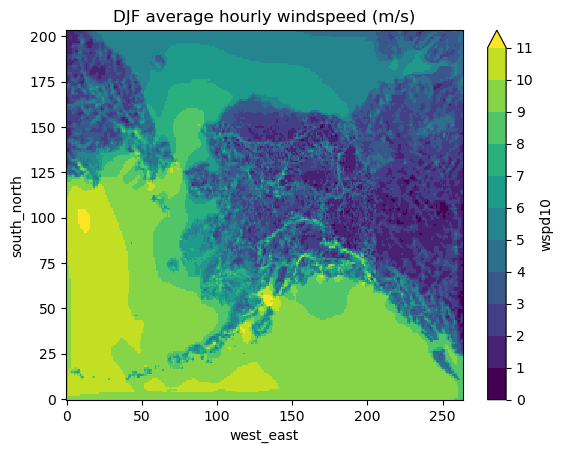

In [ ]:
levels = list(range(12))
testssn = 'DJF'
wind_byseason.sel(season=testssn).plot(levels=levels, cbar_kwargs={'ticks': levels})
plt.title(f"{testssn} average hourly windspeed (m/s)")

/tmp/ipykernel_3493381/4045135598.py:1: UserWarning: "true_scale_latitude" parameter is only used for polar stereographic projections. Consider the use of "scale_factor" instead.
  projection = ccrs.Stereographic(
/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


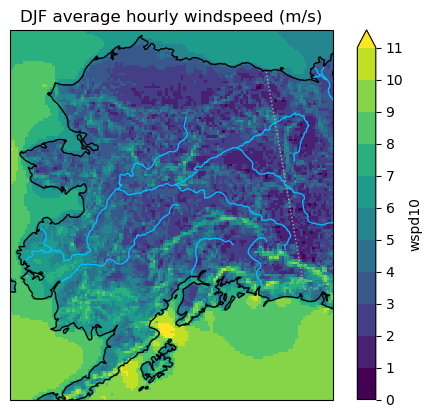

In [ ]:
projection = ccrs.Stereographic(
    central_longitude=-152.0, # central_latitude=64.0, 
    true_scale_latitude=64.0, central_latitude=64.0)

ax = plt.axes(projection=projection)
wind_byseason.sel(season=testssn).plot(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    x="XLONG", y="XLAT",
)
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"{testssn} average hourly windspeed (m/s)")
ax.set_extent([-164.35, -140.3, 55.5, 71.3])
# ax.set_extent([-180, -130, 48, 75])

In [ ]:
levels = list(range(12))
testssn = 'DJF'
wind_byseason.sel(season=testssn).plot(levels=levels, cbar_kwargs={'ticks': levels})
plt.title(f"{testssn} average hourly windspeed (m/s)")

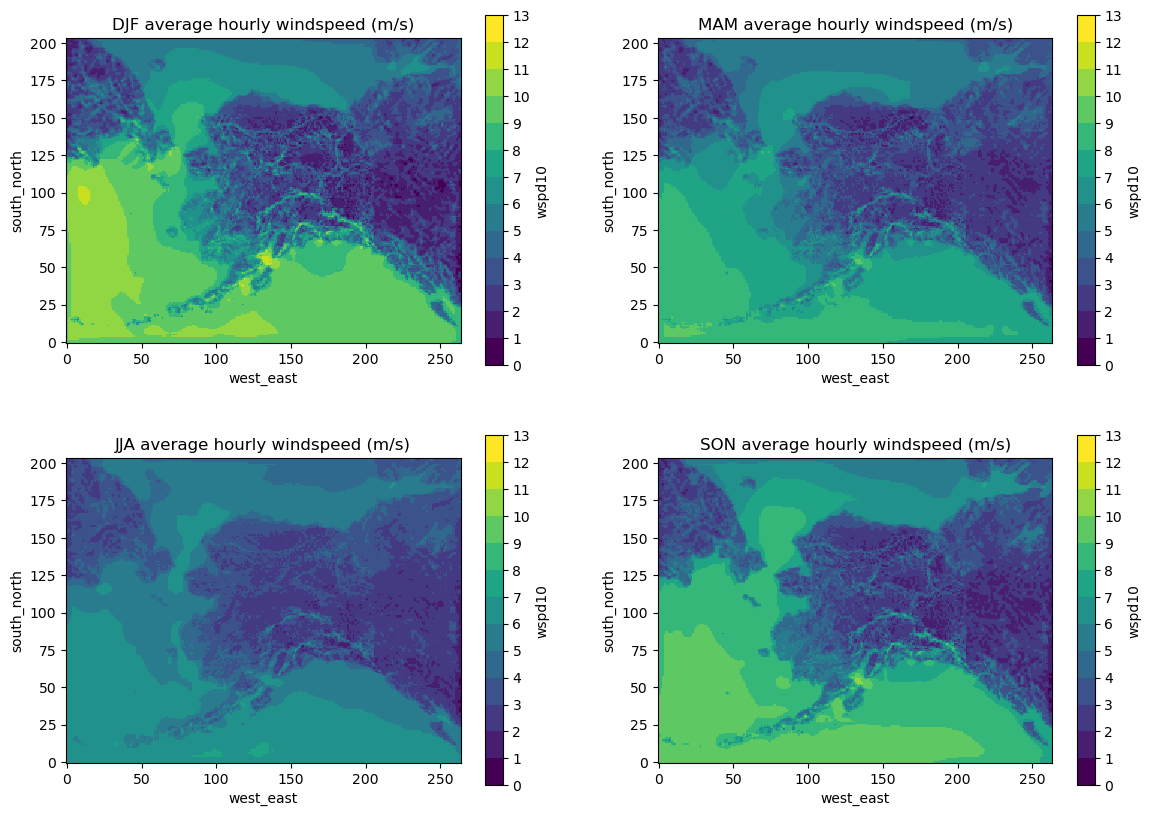

In [ ]:
levels = list(range(14))
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
for ssn, ax in zip(seasons, axes.flatten()):
    wind_byseason.sel(season=ssn).plot(
        levels=levels, cbar_kwargs={'ticks': levels},
        ax=ax)
    ax.axes.set_aspect('equal')
    ax.set_title(f"{ssn} average hourly windspeed (m/s)")

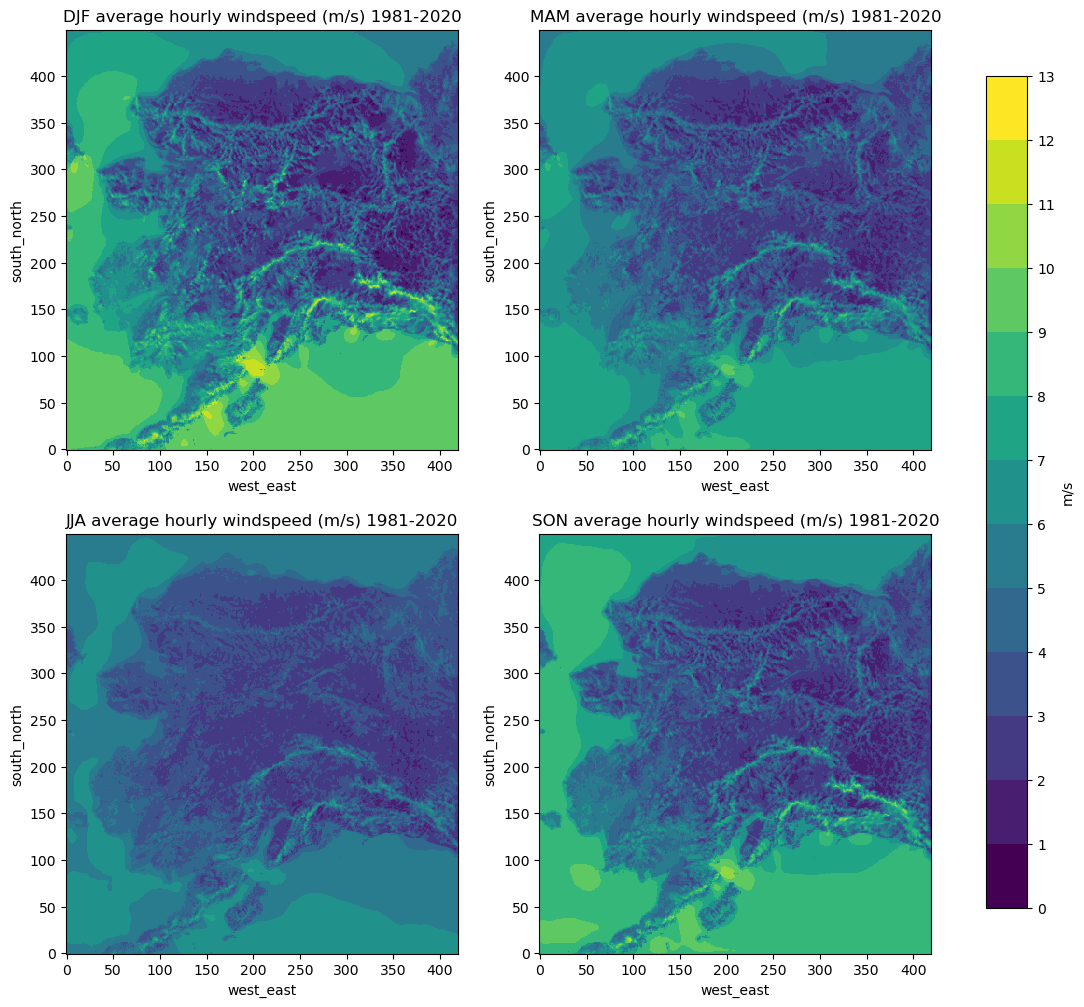

In [ ]:
levels = list(range(14))
seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        levels=levels,
        ax=ax, add_colorbar=False)
    ax.axes.set_aspect('equal')
    ax.set_title(f"{ssn} average hourly windspeed (m/s) 1981-2020")
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=levels, shrink=0.9)
cbar.set_label('m/s')

In [ ]:
levels = list(range(14))
seasons = ["DJF", "MAM", "JJA", "SON"]
projection = ccrs.Stereographic(
    central_longitude=-152.0, # central_latitude=64.0, 
    true_scale_latitude=64.0, central_latitude=64.0)
extent = [-164.35, -140.3, 55.5, 71.3]


/tmp/ipykernel_3460419/255762012.py:3: UserWarning: "true_scale_latitude" parameter is only used for polar stereographic projections. Consider the use of "scale_factor" instead.
  projection = ccrs.Stereographic(


In [ ]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10.5), 
                         subplot_kw={'projection': projection},
                         constrained_layout=True)
for ssn, ax in zip(seasons, axes.flatten()):
    im = wind_byseason.sel(season=ssn).plot(
        levels=levels,
        transform=ccrs.PlateCarree(),
        ax=ax,
        x="XLONG", y="XLAT",
        add_colorbar=False)
    ax.set_extent(extent)
    ax.coastlines()
    ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
    ax.add_feature(cf.RIVERS, color='deepskyblue')
    ax.set_title(f"Season: {ssn}")
# fig.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), ticks=levels, 
                    shrink=0.8)
cbar.set_label('m/s')
fig.suptitle("Average hourly windspeed (m/s) 1981-2020")
# fig.subplots_adjust(wspace=0.2, hspace=0.2)


In [ ]:
fig.get_figwidth()

12.0

In [ ]:
wind_mean_4 = wind.mean(dim='time')
wind_mean_4.compute()

<xarray.DataArray 'wspd10' (south_north: 450, west_east: 420)> Size: 756kB
array([[7.801707 , 7.7721763, 7.7407584, ..., 7.9774413, 7.9847064,
        7.990318 ],
       [7.84424  , 7.8383656, 7.8180084, ..., 7.9864163, 7.9936676,
        7.9902773],
       [7.8834925, 7.884845 , 7.875498 , ..., 7.9940457, 7.9982524,
        7.9901295],
       ...,
       [6.1648483, 6.2019715, 6.239809 , ..., 5.560975 , 5.4880285,
        5.4075823],
       [6.1438355, 6.17965  , 6.2151213, ..., 5.556628 , 5.481674 ,
        5.3956914],
       [6.1350994, 6.1639566, 6.1969743, ..., 5.5680604, 5.502933 ,
        5.4207997]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 756kB -164.9 -164.9 ... -128.6
    XLAT     (south_north, west_east) float32 756kB 55.13 55.14 ... 70.53 70.52
Dimensions without coordinates: south_north, west_east

In [ ]:
pathstr = str(staticdatadir / "12km/invar/geo_em.d01.nc")
pathstr

land_12 = wrf.getvar(pathstr, 'LANDMASK')
land_12

AttributeError: 'str' object has no attribute 'variables'

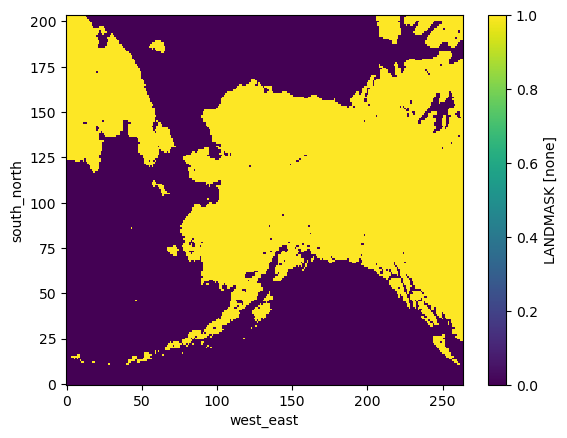

In [ ]:
invar_12 = xr.open_dataset(staticdatadir / "12km/invar/geo_em.d01.nc", engine='netcdf4')

invar_12['LANDMASK'].isel(Time=0).plot()

In [ ]:
wind_mean_12 = wind.mean(dim='time')
wind_mean_12.compute()

<xarray.DataArray 'wspd10' (south_north: 204, west_east: 264)> Size: 215kB
array([[8.660764 , 8.67181  , 8.662787 , ..., 7.62063  , 7.6113157,
        7.5986423],
       [8.698404 , 8.7472925, 8.730851 , ..., 7.6446633, 7.616762 ,
        7.5831075],
       [8.713218 , 8.77561  , 8.771167 , ..., 7.6305017, 7.5850754,
        7.537311 ],
       ...,
       [2.1873472, 2.4399107, 2.418032 , ..., 3.7336397, 3.9828978,
        4.2104654],
       [2.0656714, 2.163661 , 1.9793795, ..., 3.616826 , 3.7999525,
        4.0999746],
       [2.0886   , 1.7930793, 1.5858988, ..., 3.7445414, 3.8336852,
        3.9922402]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 215kB -174.4 -174.2 ... -108.3
    XLAT     (south_north, west_east) float32 215kB 50.55 50.59 ... 69.67 69.59
Dimensions without coordinates: south_north, west_east

Text(0.5, 1.0, 'Average hourly windspeed (m/s)')

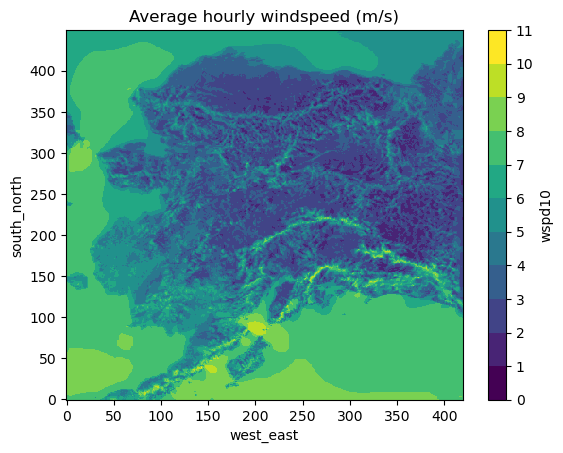

In [ ]:
levels = list(range(12))
wind_mean_4.plot(levels=levels, cbar_kwargs={'ticks': levels})
plt.title("Average hourly windspeed (m/s)")

(-0.5, 39.5, -0.5, 29.5)

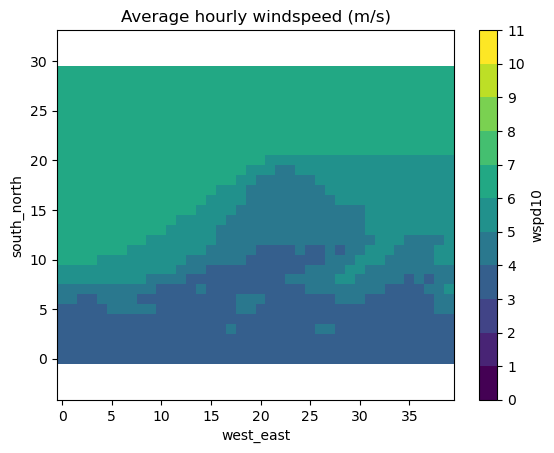

In [ ]:
levels = list(range(12))
wind_mean_4[410:440, 150:190].plot(levels=levels, cbar_kwargs={'ticks': levels})
plt.title("Average hourly windspeed (m/s)")
plt.axis('equal')

NameError: name 'wind_mean_4' is not defined

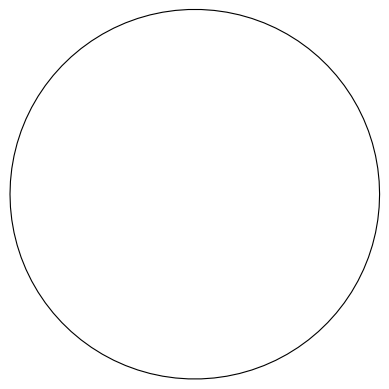

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_4.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-156.73938,71.28703, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-157.5, -155.5, 71, 71.5])

ValueError: x must be one of None, 'Time', 'south_north', 'west_east'. Received 'XLONG_M' instead.

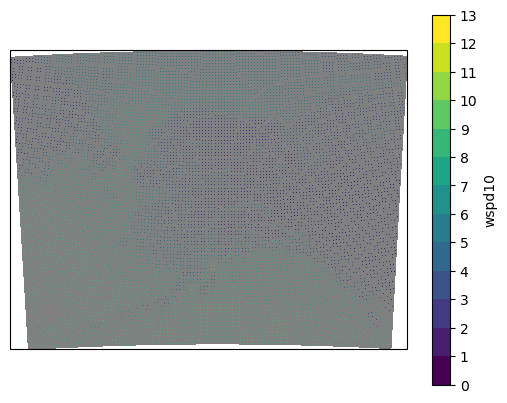

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_12.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
land.plot.pcolormesh(
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='blue', linewidth=0.4, linestyle=':',
    facecolor=None,
    x="XLONG_M", y="XLAT_M",
)
ax.plot(-156.73938,71.28703, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-157.5, -155.5, 71, 71.5])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


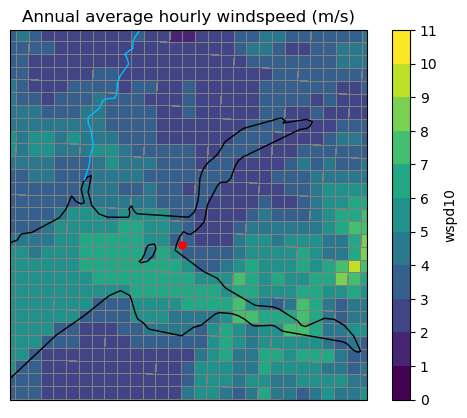

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_4.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-150.02771, 61.169163, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-151, -149, 60.75, 61.75])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


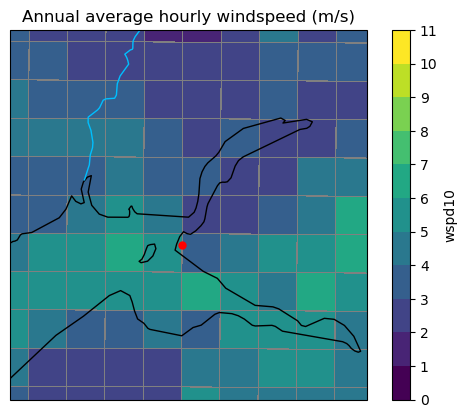

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_12.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-150.02771, 61.169163, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-151, -149, 60.75, 61.75])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


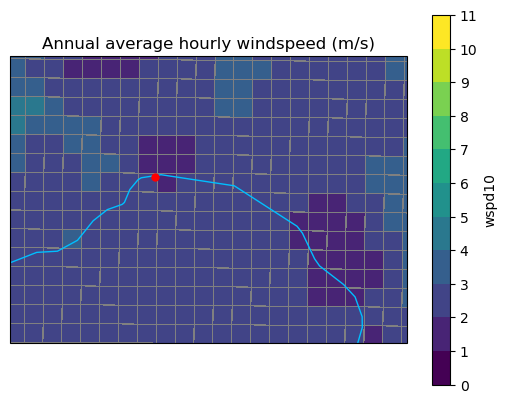

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_4.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-147.87605,64.80309, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-148.5, -146.8, 64.5, 65])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


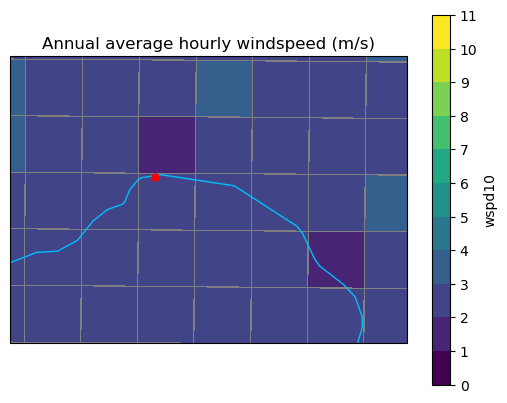

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_12.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-147.87605,64.80309, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-148.5, -146.8, 64.5, 65])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


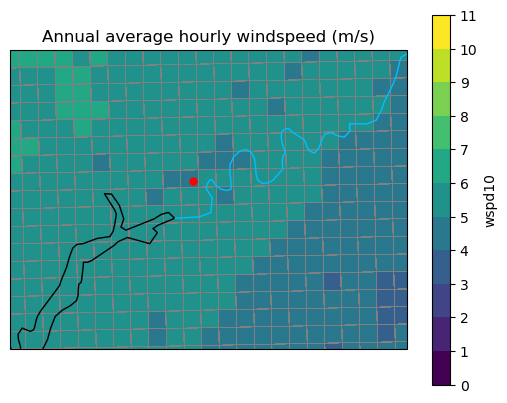

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_4.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-161.82932,60.78497, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-162.5, -161, 60.5, 61])

/import/SNAP/cwaigl/dyndowntools/.pixi/envs/default/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


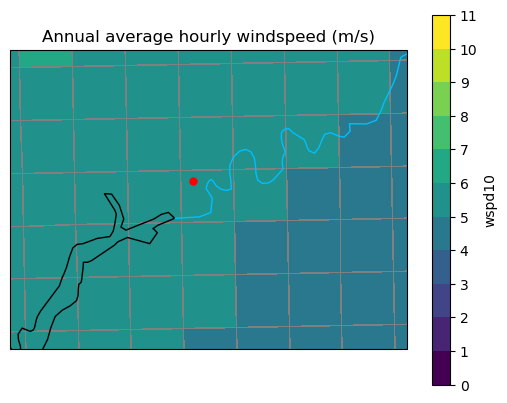

In [ ]:
ax = plt.axes(projection=projection)
wind_mean_12.plot.pcolormesh(
    levels=levels, cbar_kwargs={'ticks': levels},
    transform=ccrs.PlateCarree(),
    ax=ax,
    edgecolor='grey', linewidth=0.4, linestyle=':',
    x="XLONG", y="XLAT",
)
ax.plot(-161.82932,60.78497, 'ro', markersize=5, transform=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cf.BORDERS, linestyle=':', color='darkgrey')
ax.add_feature(cf.RIVERS, color='deepskyblue')
plt.title(f"Annual average hourly windspeed (m/s)")
ax.set_extent([-162.5, -161, 60.5, 61])

Text(0.5, 1.0, 'Average hourly windspeed (m/s)')

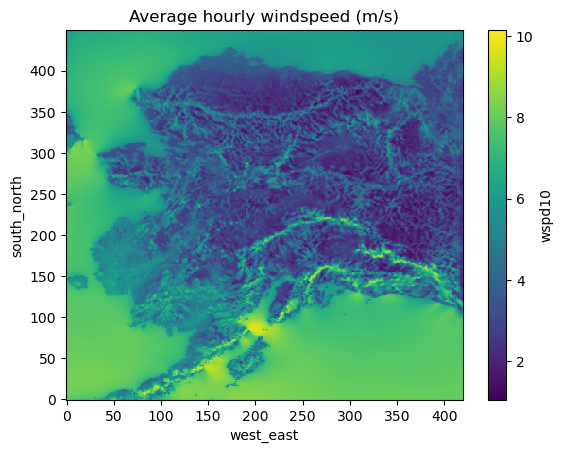

In [ ]:
wind_mean.plot()
plt.title("Average hourly windspeed (m/s)")

Text(0.5, 1.0, 'Average hourly windspeed (m/s)')

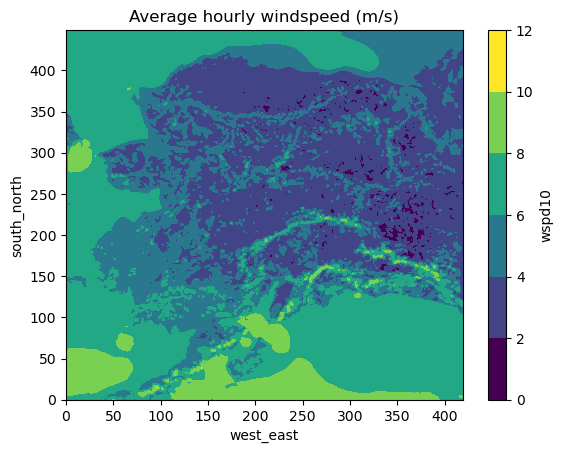

In [ ]:
wind_mean.plot.contourf( )
plt.title("Average hourly windspeed (m/s)")

Open _one_ data file to retrieve the correct i,j value

In [ ]:
testpath = next(datadir.rglob("*.nc"))

In [ ]:
testpath

PosixPath('/import/beegfs/CMIP6/wrf_era5/04km/1982/era5_wrf_dscale_4km_1982-08-21.nc')

In [ ]:
xloc, yloc = getarrayindices(test_lat, test_lon, testpath, l1norm=False)

xloc, yloc

(251, 261)

### invoke Dask explicitly 

In [ ]:
from dask.distributed import Client
client = Client(n_workers=50, threads_per_worker=2, memory_limit='50GB')

In [ ]:
# in case we need to clean up

client.shutdown()

In [ ]:
fpaths = sorted(list(datadir.rglob(f"{filepattern}*1982-08*.nc")))
ds = xr.open_mfdataset(fpaths,  
    parallel=True, 
    #chunks={'south_north': 225, 'west_east': 210, 'Time': 100},
    chunks="auto",
    # preprocess=lambda ds: ds[['rainc', 'rainnc', 'acsnow']]
    )

In [ ]:
rain = ds.rainnc + ds.rainc
rain['Time'] = rain['Time'].to_index() + dt.timedelta(hours=-8)

In [ ]:
rain

<xarray.DataArray (Time: 744, south_north: 450, west_east: 420)> Size: 562MB
dask.array<add, shape=(744, 450, 420), dtype=float32, chunksize=(24, 225, 210), chunktype=numpy.ndarray>
Coordinates:
    XLONG    (south_north, west_east) float32 756kB dask.array<chunksize=(225, 210), meta=np.ndarray>
    XLAT     (south_north, west_east) float32 756kB dask.array<chunksize=(225, 210), meta=np.ndarray>
    XTIME    (Time) float32 3kB dask.array<chunksize=(24,), meta=np.ndarray>
  * Time     (Time) datetime64[ns] 6kB 1982-07-31T16:00:00 ... 1982-08-31T15:...
Dimensions without coordinates: south_north, west_east

Exception ignored in: <function CachingFileManager.__del__ at 0x7fad8dd66fc0>
Traceback (most recent call last):
  File "/import/FIREICE/fiboreal/cwaigl/.conda/envs/dyndown/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/import/FIREICE/fiboreal/cwaigl/.conda/envs/dyndown/lib/python3.11/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2618, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2585, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2113, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


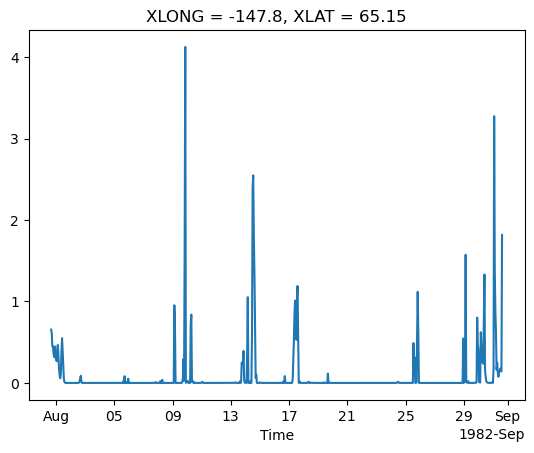

In [ ]:
rain.isel(south_north=yloc, west_east=yloc).plot()

In [ ]:
concat = []
for testdate in dates:
    with xr.open_dataset(datadir / f"{testdate[:4]}/{filepattern}_{testdate}.nc") as src:
        rain = src.rainnc + src.rainc
        rain['Time'] = rain['Time'].to_index() + dt.timedelta(hours=-8)
    concat.append(rain.isel(south_north=yloc, west_east=yloc))

In [ ]:
all_rain = xr.concat(concat, dim='Time').to_dataframe(name='rain').drop(columns=['XLAT', 'XLONG', 'XTIME'])

In [ ]:
all_rain_daily = all_rain.resample('D').sum()

<Axes: xlabel='Time'>

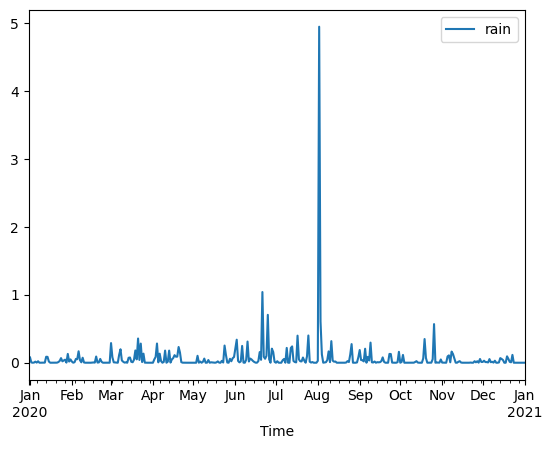

In [ ]:
all_rain_daily.plot()

### add rain from ACIS

In [ ]:
weatherstationframes[teststation]['2011-01-01':'2020-12-31']

,Tmax_f,Tmin_F,Tavg_F,precip_in,sd_m,swe,year
2011-01-01,35,-5,15.0,0.01,13,-9999,2011
2011-01-02,41,12,26.5,0.00,13,-9999,2011
2011-01-03,25,7,16.0,0.00,13,-9999,2011
2011-01-04,30,13,21.5,0.01,12,-9999,2011
2011-01-05,23,-6,8.5,0.00,12,-9999,2011
...,...,...,...,...,...,...,...
2020-12-27,9,-13,-2.0,0.00,15,-9999,2020
2020-12-28,20,2,11.0,0.00,15,-9999,2020
2020-12-29,19,-8,5.5,0.00,15,-9999,2020
2020-12-30,1,-10,-4.5,0.00,15,-9999,2020


In [ ]:
precipDF = pd.DataFrame(weatherstationframes[teststation]['precip_in'] * 2.54)
precipDF.replace(-9999* 2.54, np.nan, inplace=True)
precipDF.columns = ['precip_cm']
precipDF['2011-01-01':'2020-12-31']

,precip_cm
2011-01-01,0.0254
2011-01-02,0.0000
2011-01-03,0.0000
2011-01-04,0.0254
2011-01-05,0.0000
...,...
2020-12-27,0.0000
2020-12-28,0.0000
2020-12-29,0.0000
2020-12-30,0.0000


<Axes: >

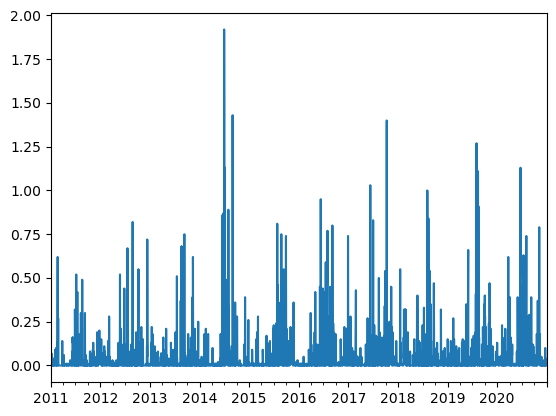

In [ ]:
weatherstationframes[teststation]['2011-01-01':'2020-12-31']['precip_in'].plot()
# plt.ylim([0, 1])

<Axes: xlabel='Time'>

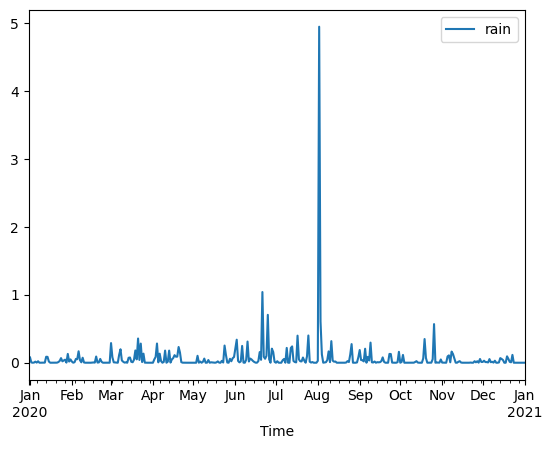

In [ ]:
all_rain_daily.plot()

In [ ]:
compDF = all_rain_daily[1:-1].merge(precipDF['2020-01-01':'2020-12-31'], left_index=True, right_index=True )
compDF

,rain,precip_mm
Time,,
2020-01-01,0.083123,6.096
2020-01-02,0.004121,0.254
2020-01-03,0.000000,0.000
2020-01-04,0.002172,0.000
2020-01-05,0.015902,0.000
...,...,...
2020-12-27,0.000163,0.000
2020-12-28,0.000391,0.254
2020-12-29,0.000160,0.000


In [ ]:
compDF['month'] = compDF.index.month

In [ ]:
compDF

,rain,precip_mm,month
Time,,,
2020-01-01,0.083123,6.096,1
2020-01-02,0.004121,0.254,1
2020-01-03,0.000000,0.000,1
2020-01-04,0.002172,0.000,1
2020-01-05,0.015902,0.000,1
...,...,...,...
2020-12-27,0.000163,0.000,12
2020-12-28,0.000391,0.254,12
2020-12-29,0.000160,0.000,12


In [ ]:
import seaborn as sns

(0.0, 10.0)

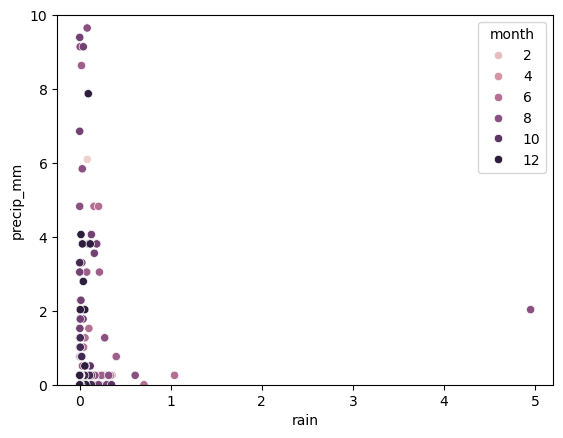

In [ ]:
ax = sns.scatterplot(data=compDF, x='rain', y='precip_mm', hue='month')
ax.set_ylim([0, 10])


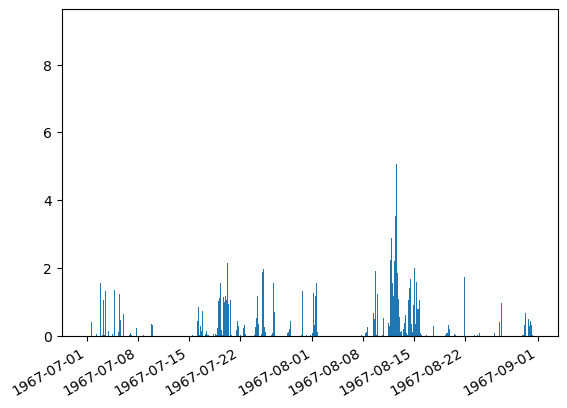

In [ ]:
interval = dt.timedelta(hours=1)     # <----- timedelta of 1 hour

fig, ax = plt.subplots()
ax.bar(all_rain.index, all_rain.rain, width=interval)
fig.autofmt_xdate()

### Comparison w/ NCEI hourly data

In [ ]:
rainDF = pd.read_csv('FAI_PAFA_hourly_precip_NCEI.csv')
rainDF['datetime'] = pd.to_datetime(rainDF.DATE)
rainDF['HPCP'] = rainDF.HPCP.replace(999.99, 0).replace(0.01, 0) * 25.4
rainDF

,STATION,STATION_NAME,DATE,HPCP,datetime
0,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,19500101 01:00,0.000,1950-01-01 01:00:00
1,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,19500101 11:00,0.762,1950-01-01 11:00:00
2,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,19500101 12:00,0.508,1950-01-01 12:00:00
3,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,19500101 13:00,0.508,1950-01-01 13:00:00
4,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,19500101 14:00,0.762,1950-01-01 14:00:00
...,...,...,...,...,...
42191,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,20131001 13:00,0.000,2013-10-01 13:00:00
42192,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,20131101 01:00,0.000,2013-11-01 01:00:00
42193,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,20131201 00:00,0.000,2013-12-01 00:00:00
42194,COOP:502968,FAIRBANKS INTERNATIONAL AIRPORT AK US,20131201 01:00,0.000,2013-12-01 01:00:00


In [ ]:
dt.datetime.strptime(startdate, '%Y-%m-%d')

datetime.datetime(1967, 7, 1, 0, 0)

In [ ]:
mask = ((rainDF['datetime'] > dt.datetime.strptime(startdate, '%Y-%m-%d')) & 
        (rainDF['datetime'] <= dt.datetime.strptime(enddate, '%Y-%m-%d')))

In [ ]:
bothDF = rainDF.loc[mask].drop(columns=['STATION', 'STATION_NAME', 'DATE']).set_index('datetime').merge(all_rain, how='left', left_index=True, right_index=True)
bothDF.columns = ['COOP:502968', 'ERA5 4 km']

Text(0, 0.5, 'mm')

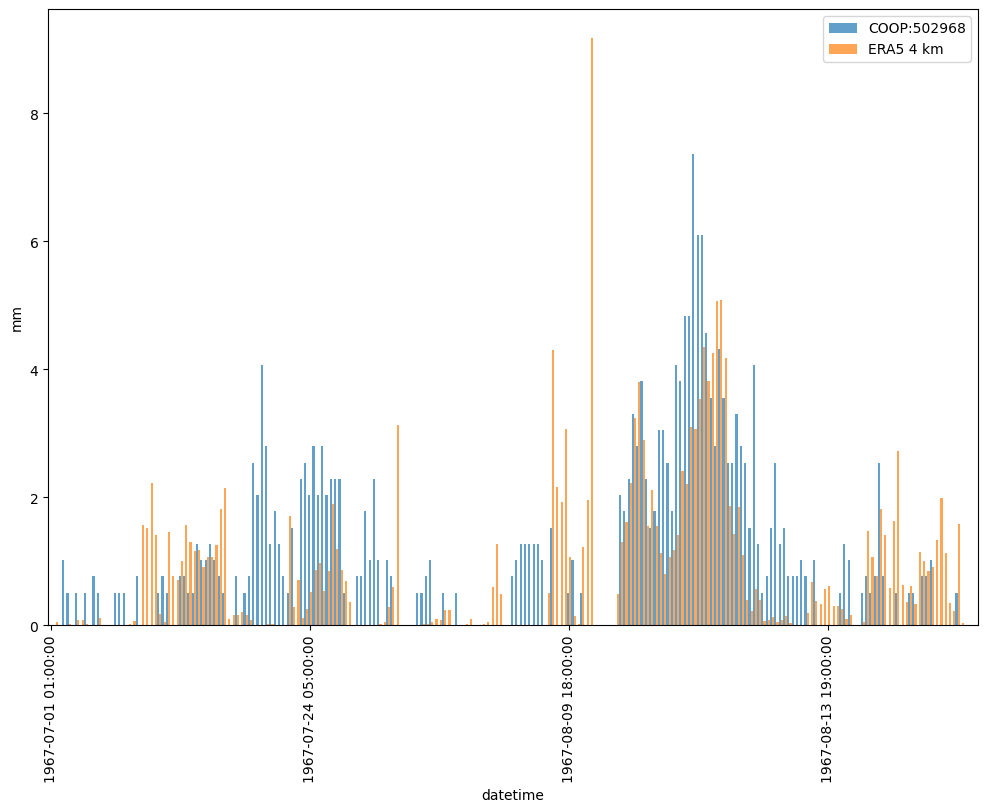

In [ ]:
from matplotlib.ticker import MultipleLocator
fig, ax = plt.subplots(figsize=(12, 8))
bothDF.plot(kind='bar', alpha=0.7, width=1, ax=ax)
ax.xaxis.get_major_locator()                    # <matplotlib.ticker.FixedLocator at 0x2221f657340>
ax.xaxis.get_major_formatter()                  # <matplotlib.ticker.FuncFormatter at 0x2221f8e2a00>

ax.xaxis.set_major_locator(MultipleLocator(60))  # show every 5th tick
plt.ylabel('mm')

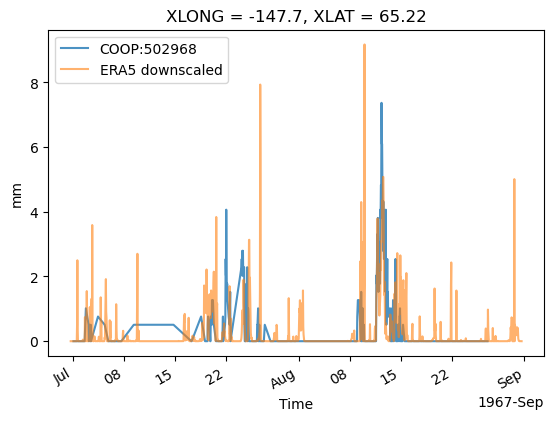

In [ ]:
ax = (rainDF.loc[mask].set_index('datetime').HPCP).plot(label='COOP:502968', alpha=0.8)
xr.concat(concat, dim='Time').plot(ax=ax, alpha=0.6, label='ERA5 downscaled')
plt.ylabel('mm')
plt.legend()